<a href="https://colab.research.google.com/github/sherechogaki/WineQualityNotebook/blob/main/wine_quality_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Prediction
**Dataset:** UCI Wine Quality (Cortez et al., 2009)  
**Goal:** Predict wine quality score from physicochemical features  
**Algorithms:** Decision Tree, Random Forest, KNN, Logistic Regression, Naive Bayes, SVM, ANN

## How to use this notebook
1. Upload `winequality-red.csv` and `winequality-white.csv` when prompted in Cell 2
2. Run cells **top to bottom** — each cell builds on the previous one
3. Read the markdown explanations before each code cell — they explain the *why*


## Install & Import Libraries
We install and import everything we need upfront so nothing breaks later.

| Library | Purpose |
|---|---|
| `pandas` | Load and manipulate CSV data |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Plotting and visualisation |
| `sklearn` | All machine learning algorithms and tools |

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn — algorithms
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')

✅ All libraries imported successfully!



##  Load the Dataset
Upload both CSV files from UCI when the file picker appears.

The files use semicolons (;) as separators, not commas — that's why we use `sep=';'`.

In [ ]:
from google.colab import files

print('📁 Please upload winequality-red.csv and winequality-white.csv')
uploaded = files.upload()

# Load both datasets
red   = pd.read_csv('winequality-red.csv',   sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# Add a 'wine_type' column so we can identify rows if we ever merge them
red['wine_type']   = 'red'
white['wine_type'] = 'white'

print(f'\n Red wine loaded:   {red.shape[0]} rows, {red.shape[1]} columns')
print(f' White wine loaded: {white.shape[0]} rows, {white.shape[1]} columns')

print('\n🔍 First 3 rows of red wine:')
red.head(3)

📁 Please upload winequality-red.csv and winequality-white.csv


Saving winequality-red.csv to winequality-red.csv
Saving winequality-white.csv to winequality-white.csv

✅ Red wine loaded:   1599 rows, 13 columns
✅ White wine loaded: 4898 rows, 13 columns

🔍 First 3 rows of red wine:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red



## Exploratory Data Analysis (EDA)
EDA means *looking at your data before modelling it*. The goal is to understand:
- What's in the data (distributions, ranges)
- Whether there are problems (missing values, duplicates, outliers)
- Which features are likely to matter (correlations)

## Basic Dataset Info
Shape, data types, missing values, and duplicates.

In [ ]:
for name, df in [('RED WINE', red), ('WHITE WINE', white)]:
    print(f'{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'Shape          : {df.shape[0]} rows × {df.shape[1]} columns')
    print(f'Missing values : {df.isnull().sum().sum()} total')
    print(f'Duplicate rows : {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.1f}%)')
    print(f'Quality range  : {df["quality"].min()} – {df["quality"].max()}')
    print()

# drop duplicates
# Both datasets have significant duplicates. We drop them to avoid
# the model simply memorising repeated rows.
red_clean   = red.drop_duplicates().reset_index(drop=True)
white_clean = white.drop_duplicates().reset_index(drop=True)

print(f'After removing duplicates:')
print(f'  Red wine   : {len(red_clean)} rows  (removed {len(red)-len(red_clean)})')
print(f'  White wine : {len(white_clean)} rows (removed {len(white)-len(white_clean)})')

  RED WINE
Shape          : 1599 rows × 13 columns
Missing values : 0 total
Duplicate rows : 240 (15.0%)
Quality range  : 3 – 8

  WHITE WINE
Shape          : 4898 rows × 13 columns
Missing values : 0 total
Duplicate rows : 937 (19.1%)
Quality range  : 3 – 9

After removing duplicates:
  Red wine   : 1359 rows  (removed 240)
  White wine : 3961 rows (removed 937)


---
## Descriptive Statistics
`describe()` gives you mean, std, min, max and quartiles for every feature at once.  
Look for features with very large ranges — those will need scaling later.

In [ ]:
print(' RED WINE — Descriptive Statistics')
display(red_clean.describe().round(3))

print('\n WHITE WINE — Descriptive Statistics')
display(white_clean.describe().round(3))

📊 RED WINE — Descriptive Statistics


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000,1359.000
mean,8.311,0.529,0.272,2.523,0.088,15.893,46.826,0.997,3.310,0.659,10.432,5.623
std,1.737,0.183,0.196,1.352,0.049,10.447,33.409,0.002,0.155,0.171,1.082,0.824
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.430,2.600,0.091,21.000,63.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000



📊 WHITE WINE — Descriptive Statistics


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000,3961.000
mean,6.839,0.281,0.334,5.915,0.046,34.889,137.194,0.994,3.195,0.490,10.589,5.855
std,0.867,0.103,0.122,4.862,0.023,17.210,43.129,0.003,0.152,0.114,1.217,0.891
min,3.800,0.080,0.000,0.600,0.009,2.000,9.000,0.987,2.720,0.220,8.000,3.000
25%,6.300,0.210,0.270,1.600,0.035,23.000,106.000,0.992,3.090,0.410,9.500,5.000
50%,6.800,0.260,0.320,4.700,0.042,33.000,133.000,0.994,3.180,0.480,10.400,6.000
75%,7.300,0.330,0.390,8.900,0.050,45.000,166.000,0.996,3.290,0.550,11.400,6.000
max,14.200,1.100,1.660,65.800,0.346,289.000,440.000,1.039,3.820,1.080,14.200,9.000


---
##Quality Score Distribution
**class imbalance**  
Most wines score 5 or 6. Very few score 3, 4, 8, or 9. This means:
- A model that always predicts 5 or 6 would get ~50-60% accuracy for free
-  we need F1 - score, not just accuracy, to evaluate fairly

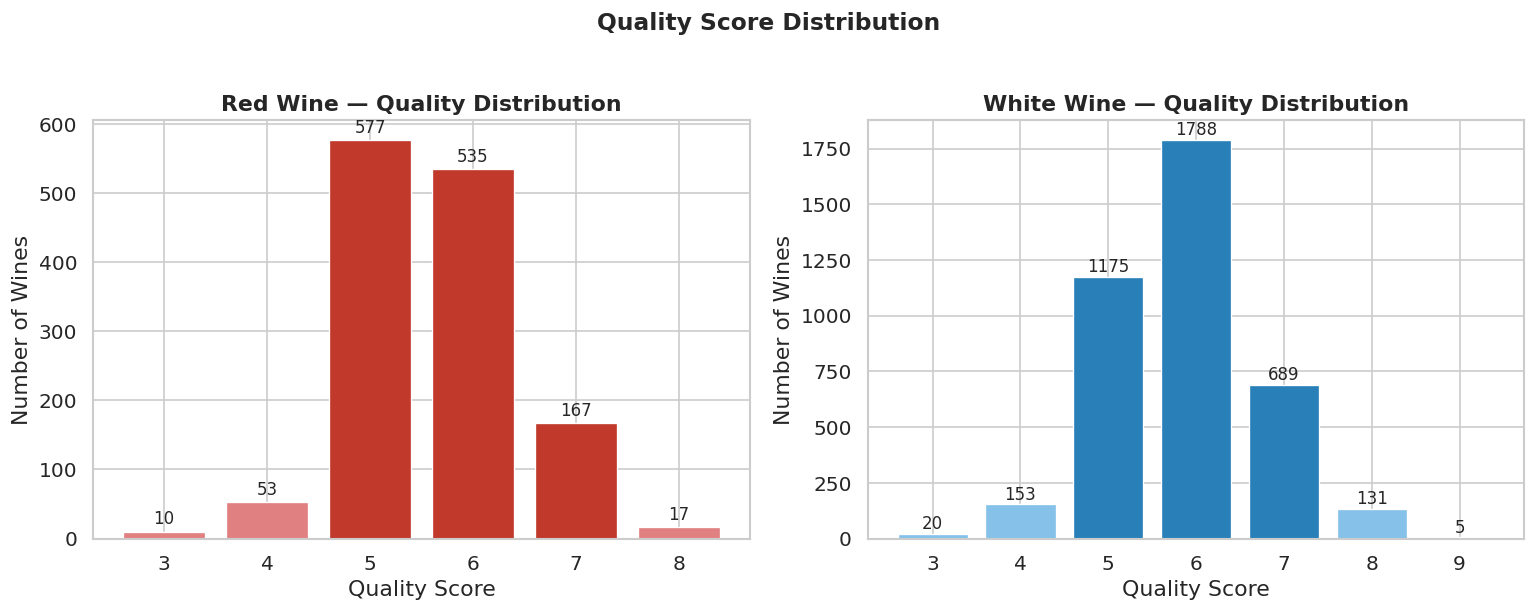

💾 Saved: quality_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_red   = ['#c0392b' if v in [5,6,7] else '#e08080' for v in sorted(red_clean['quality'].unique())]
colors_white = ['#2980b9' if v in [5,6,7] else '#85c1e9' for v in sorted(white_clean['quality'].unique())]

for ax, df, name, colors in [
    (axes[0], red_clean,   'Red Wine',   colors_red),
    (axes[1], white_clean, 'White Wine', colors_white)
]:
    counts = df['quality'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{name} — Quality Distribution', fontweight='bold')
    ax.set_xlabel('Quality Score')
    ax.set_ylabel('Number of Wines')
    ax.set_xticks(counts.index)
    # Add count labels on top of bars
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontsize=10)

plt.suptitle('Quality Score Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('quality_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Feature Distributions
Plot a histogram for each of the 11 features.  
**What to look for:**
- **Right-skewed** (long tail on the right)
- **Normal-shaped**: no special treatment needed
- **Very narrow range**: might not be useful

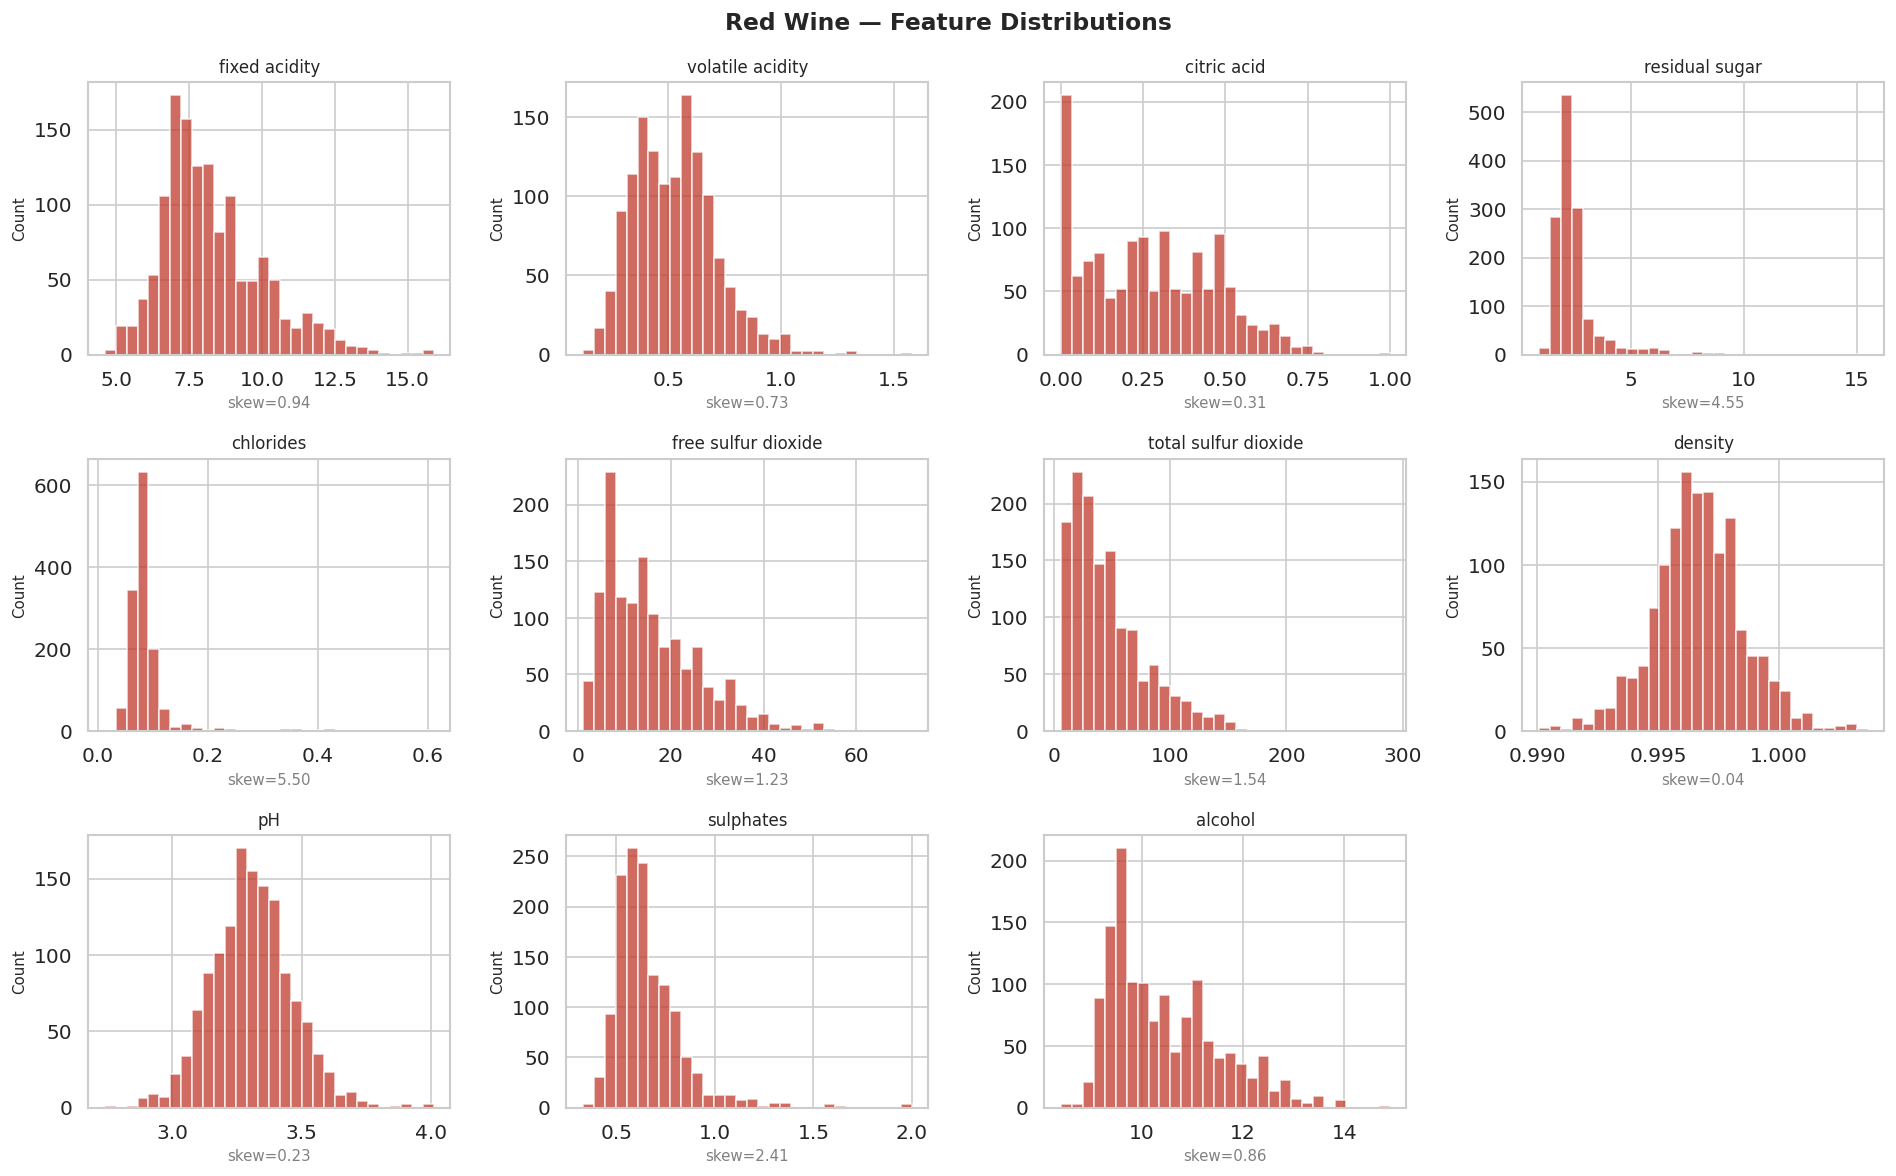

💾 Saved: red_wine_distributions.png


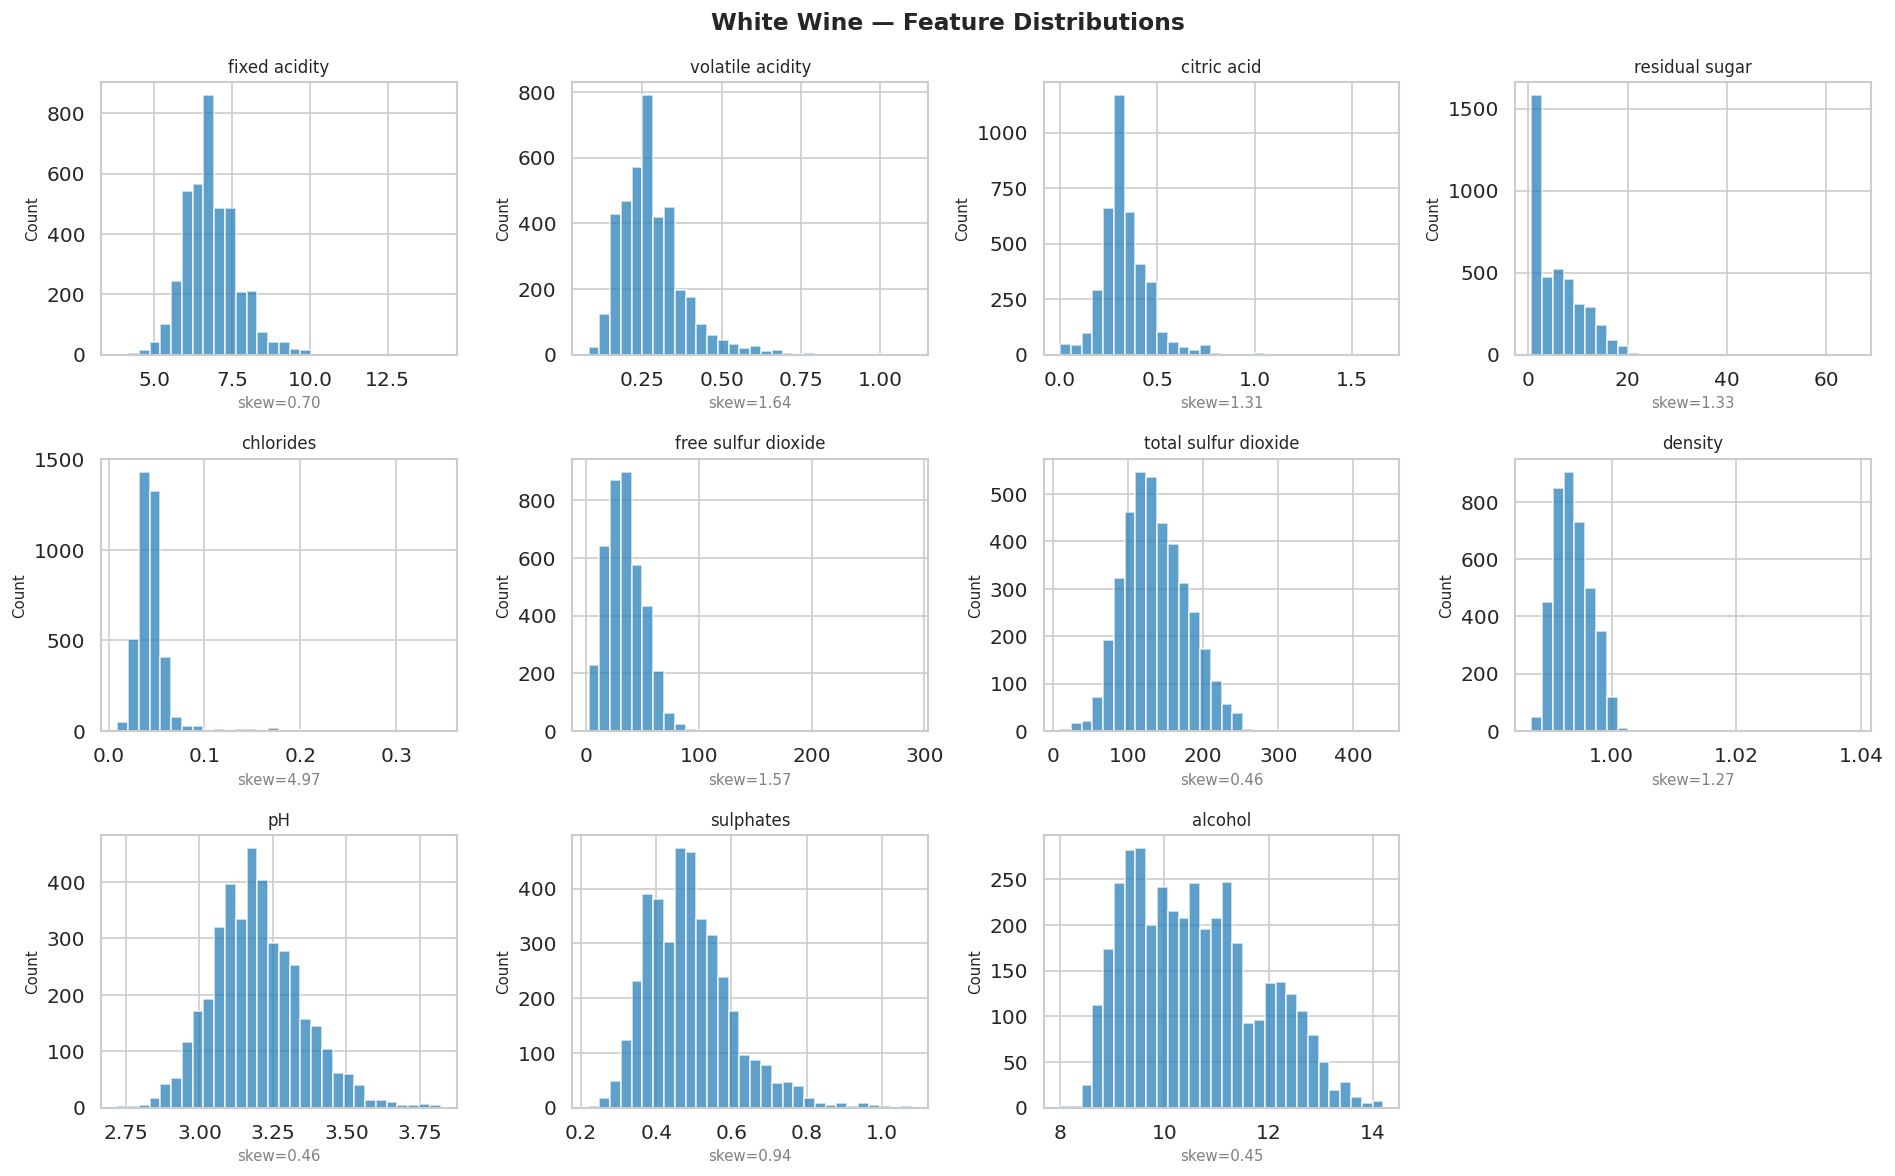

💾 Saved: white_wine_distributions.png


In [ ]:
features = [c for c in red_clean.columns if c not in ['quality', 'wine_type']]

for df, name, color in [
    (red_clean, 'Red Wine', '#c0392b'),
    (white_clean, 'White Wine', '#2980b9')
]:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    fig.suptitle(f'{name} — Feature Distributions', fontsize=14, fontweight='bold')

    for i, feat in enumerate(features):
        ax = axes[i // 4][i % 4]
        ax.hist(df[feat], bins=30, color=color, alpha=0.75, edgecolor='white')
        ax.set_title(feat, fontsize=10)
        skew = df[feat].skew()
        ax.set_xlabel(f'skew={skew:.2f}', fontsize=9, color='gray')
        ax.set_ylabel('Count', fontsize=9)

    # Hide the empty 12th subplot
    axes[2][3].axis('off')
    plt.tight_layout()
    fname = f'{name.lower().replace(" ","_")}_distributions.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

---
## Correlation Heatmap
The correlation matrix shows how much any two variables move together (−1 to +1).  
the last row/column(quality) values tell us which features are most predictive.  
highly correlated feature pairs are redundant and may hurt some models.

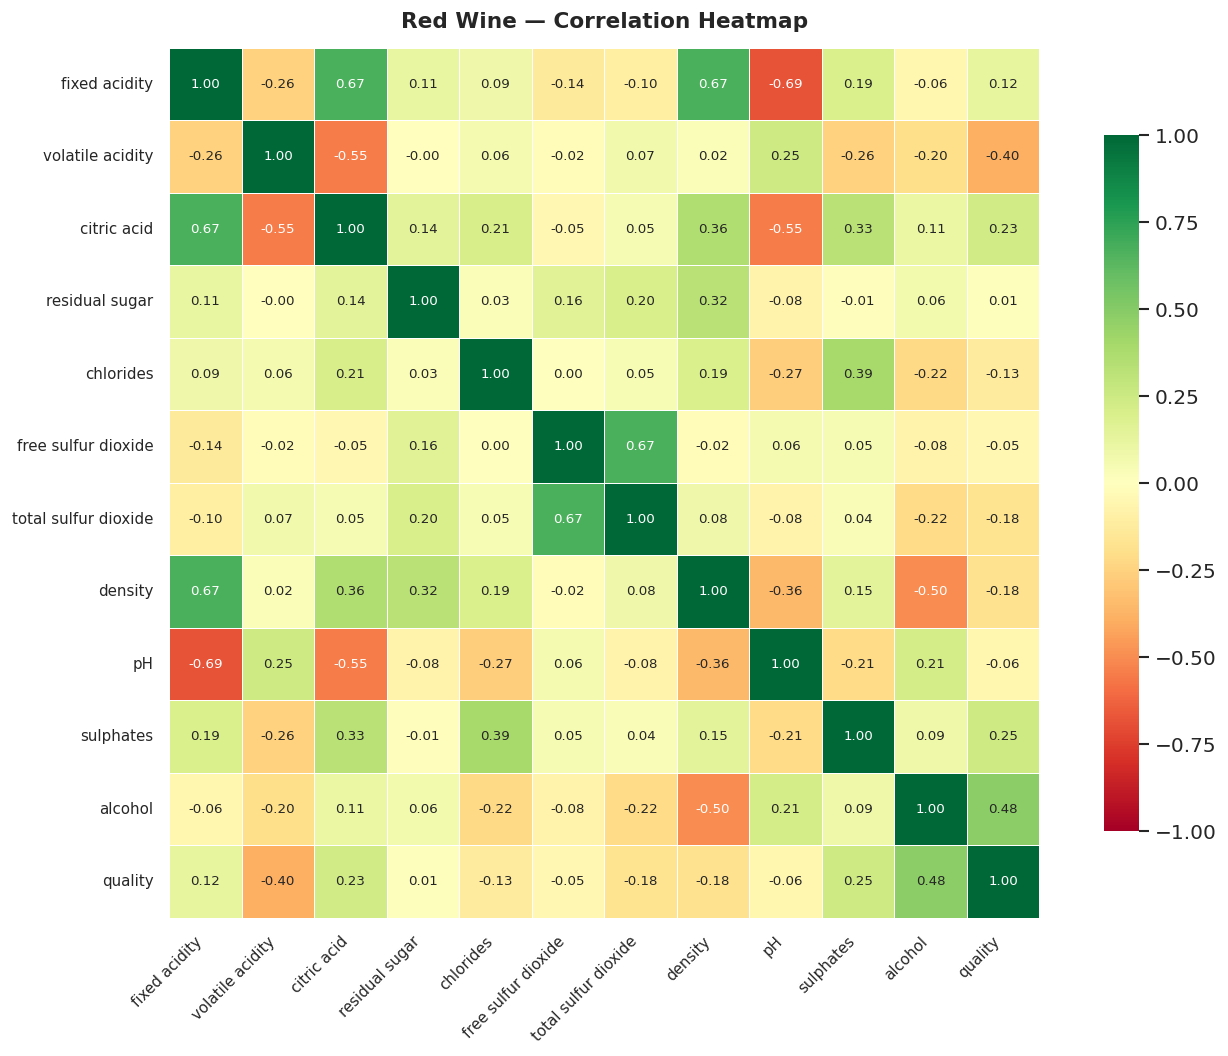

💾 Saved: red_wine_heatmap.png

📌 Red Wine — Top correlations with quality:
  alcohol                +0.480  █████████
  volatile acidity       -0.395  ███████
  sulphates              +0.249  ████
  citric acid            +0.228  ████
  density                -0.184  ███
  total sulfur dioxide   -0.178  ███
  chlorides              -0.131  ██
  fixed acidity          +0.119  ██
  pH                     -0.055  █
  free sulfur dioxide    -0.050  █
  residual sugar         +0.014  



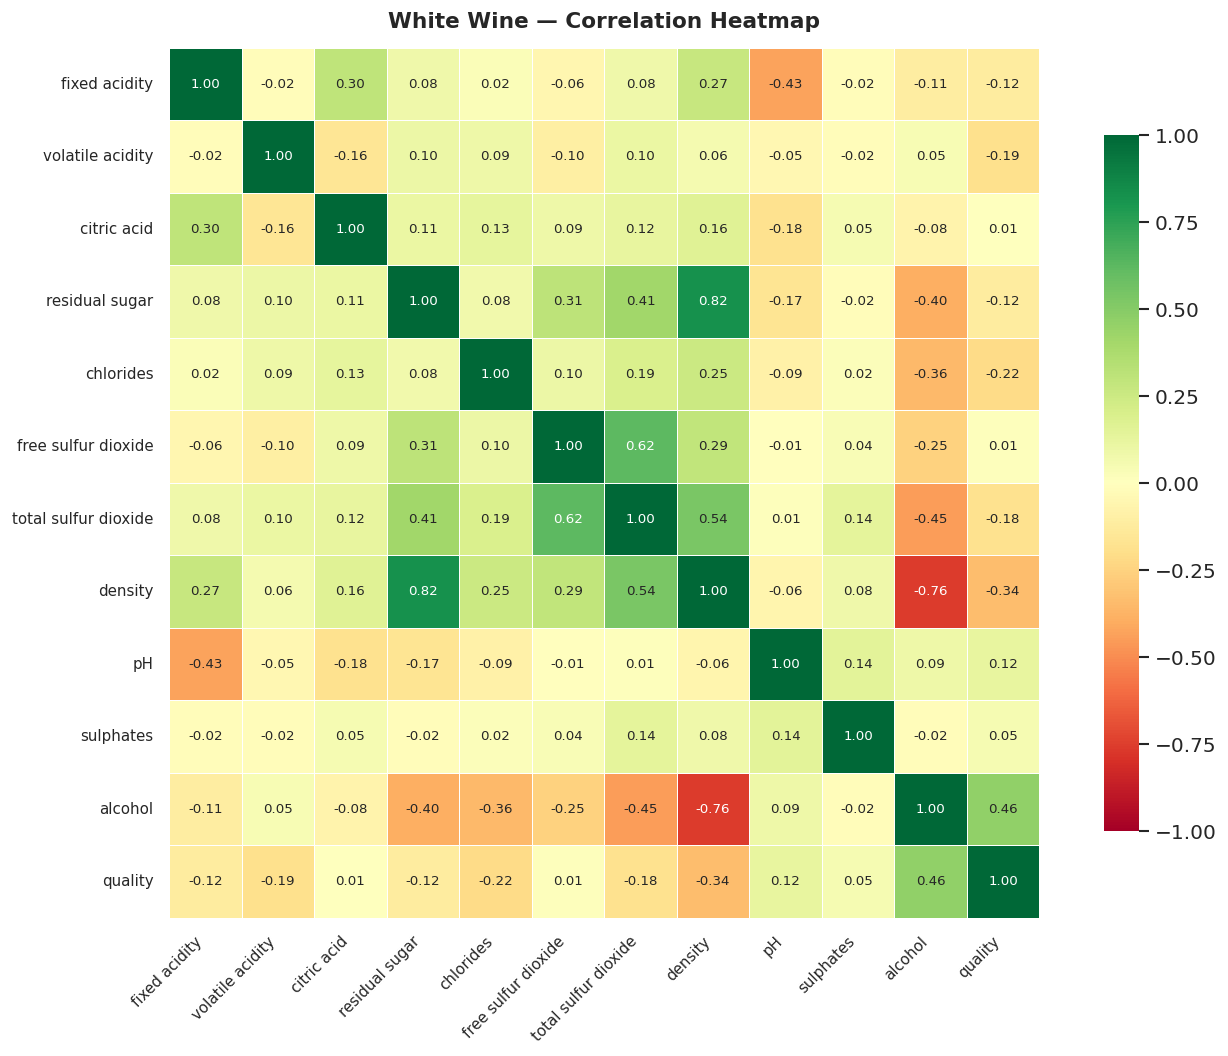

💾 Saved: white_wine_heatmap.png

📌 White Wine — Top correlations with quality:
  alcohol                +0.463  █████████
  density                -0.338  ██████
  chlorides              -0.218  ████
  volatile acidity       -0.191  ███
  total sulfur dioxide   -0.183  ███
  fixed acidity          -0.125  ██
  pH                     +0.124  ██
  residual sugar         -0.117  ██
  sulphates              +0.053  █
  free sulfur dioxide    +0.011  
  citric acid            +0.007  



In [ ]:
for df, name in [(red_clean, 'Red Wine'), (white_clean, 'White Wine')]:
    # Exclude wine_type column for correlation
    df_num = df.drop(columns=['wine_type'])
    corr = df_num.corr()

    plt.figure(figsize=(12, 9))
    mask = np.zeros_like(corr, dtype=bool)  # show full matrix

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        linecolor='white',
        square=True,
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'{name} — Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    fname = f'{name.lower().replace(" ","_")}_heatmap.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

    # Print top correlations with quality
    print(f'\n {name} — Top correlations with quality:')
    corr_quality = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
    for feat, val in corr_quality.items():
        bar = '█' * int(abs(val) * 20)
        sign = '+' if val > 0 else '-'
        print(f'  {feat:<22} {sign}{abs(val):.3f}  {bar}')
    print()


## Boxplots: Features vs Quality
Boxplots show whether each feature's values differ meaningfully across quality scores.  
If a feature's boxes don't overlap much across quality levels → it's a useful predictor.  

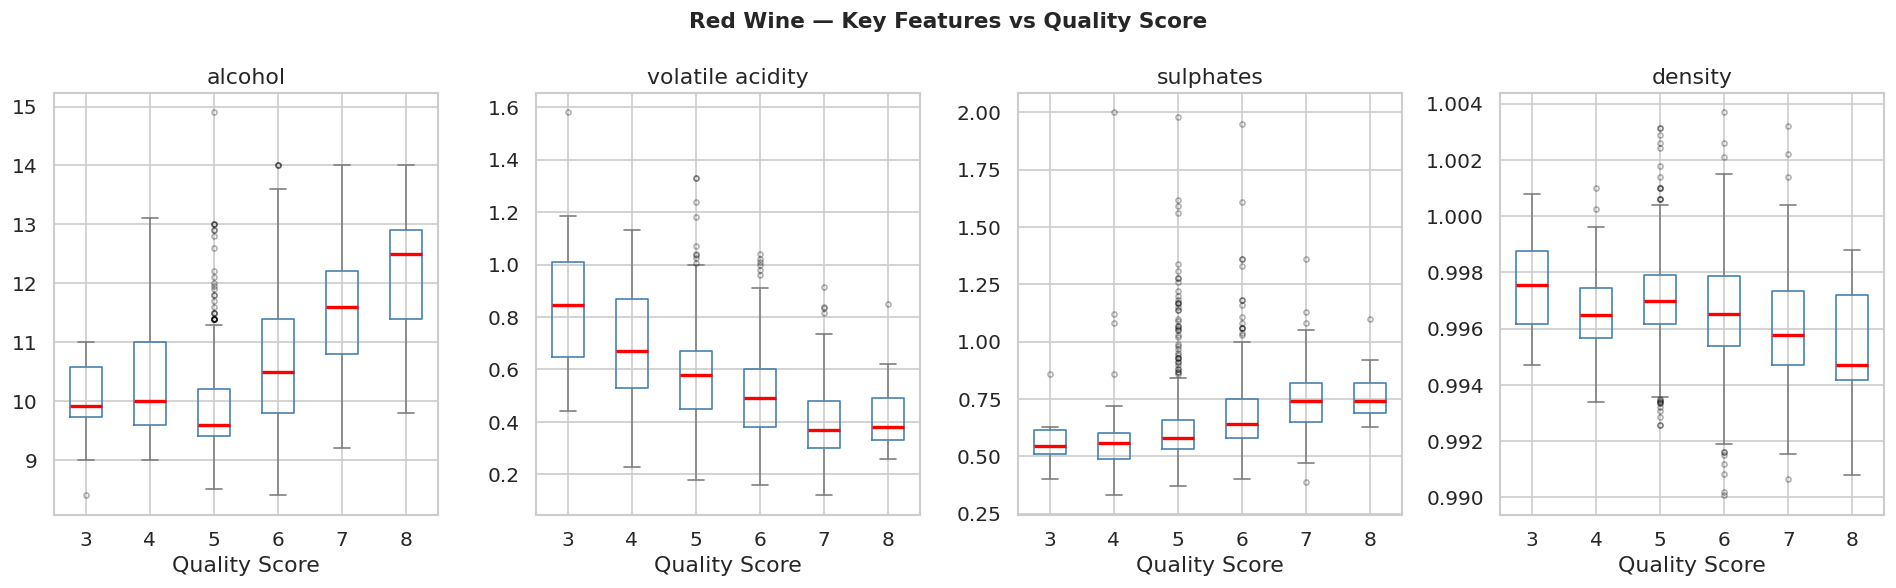

💾 Saved: red_wine_boxplots.png


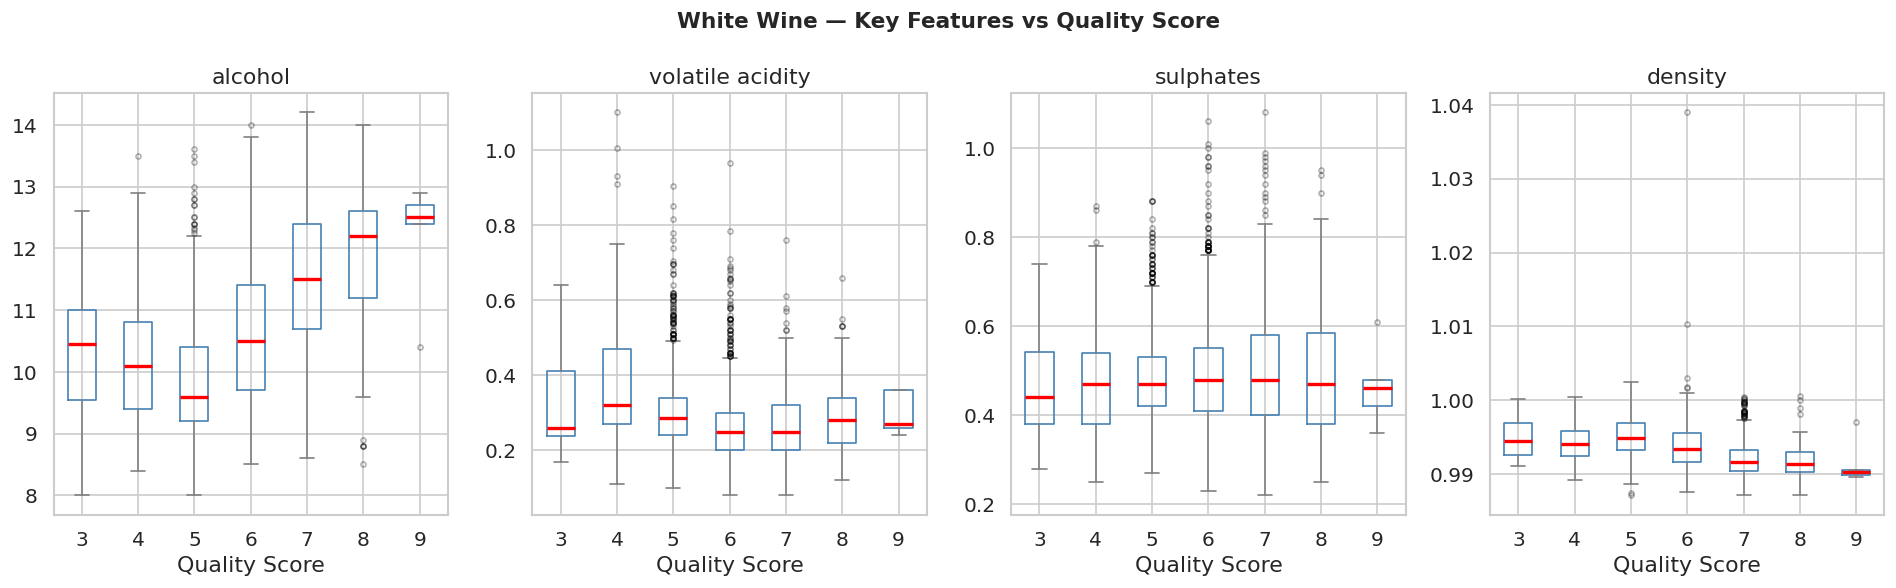

💾 Saved: white_wine_boxplots.png


In [ ]:
# Plot the 4 most correlated features vs quality for each wine
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'density']

for df, name, palette in [
    (red_clean,   'Red Wine',   'Reds'),
    (white_clean, 'White Wine', 'Blues')
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle(f'{name} — Key Features vs Quality Score', fontsize=13, fontweight='bold')

    for ax, feat in zip(axes, top_features):
        df.boxplot(column=feat, by='quality', ax=ax,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='gray'),
                   capprops=dict(color='gray'),
                   flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('Quality Score')
        plt.sca(ax)
        plt.title(feat)

    plt.suptitle(f'{name} — Key Features vs Quality Score', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'{name.lower().replace(" ","_")}_boxplots.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

## Quality Score Distribution

Before training any model, we examine how quality scores are distributed across the dataset.
This is one of the most important steps in regression analysis — it tells us which score
values the model will see frequently (and therefore learn well) versus rarely (and therefore
struggle with).

The `value_counts()` function counts how many wines received each quality score, sorted
from lowest to highest. The mean and standard deviation summarise the central tendency
and spread of the target variable.

**What to look for:**
- **Imbalance:** Are most wines clustered around scores 5 and 6? If so, the model sees
  very few examples of score 3, 4, 8, or 9 — predicting those extremes will be harder.
- **Mean:** A mean near 5.5–6.0 confirms that "average" quality dominates the dataset.
- **Std:** A standard deviation below 1.0 means scores are tightly packed — the model
  has a narrow range of variation to learn from, which partly explains why R² values
  tend to be moderate rather than high.

This distribution is **not a problem to fix** — it reflects the real world, where
exceptional and very poor wines are genuinely rare. However, it does mean that accuracy
metrics should be interpreted carefully: a model predicting "6" for every wine would
already achieve a low error just by exploiting this imbalance.

In [ ]:
# Target variable is 'quality' directly (integer 3–9)

for name, df in [('Red Wine', red_clean), ('White Wine', white_clean)]:
    print(f'{name} — Quality score distribution:')
    print(df['quality'].value_counts().sort_index().to_dict())
    print(f'  Mean: {df["quality"].mean():.2f}  |  Std: {df["quality"].std():.2f}\n')

Red Wine — Quality score distribution:
{3: 10, 4: 53, 5: 577, 6: 535, 7: 167, 8: 17}
  Mean: 5.62  |  Std: 0.82

White Wine — Quality score distribution:
{3: 20, 4: 153, 5: 1175, 6: 1788, 7: 689, 8: 131, 9: 5}
  Mean: 5.85  |  Std: 0.89



##Train / Test Split

Before training any model, we need to divide the dataset into two separate sets:

- **Training set (80%):** The data the model learns from — it sees these rows during training.
- **Test set (20%):** Data the model has *never seen* during training — used only to evaluate
  how well it generalises to new wines.

This separation is fundamental to honest evaluation. If you tested on the same data you
trained on, the model could simply memorise the answers and report near-perfect accuracy
without actually learning anything useful. The test set simulates real-world deployment
where the model encounters wines it has never seen before.

**Breaking down the code:**

- `FEATURES` — we first define which columns are inputs by excluding the target (`quality`)
  and the helper column (`wine_type`). This gives us the 11 physicochemical features.
- `X` — the feature matrix (inputs). Shape: (n_samples, 11).
- `y` — the target vector (quality scores). A single column of integers from 3 to 9.
- `test_size=0.2` — reserves 20% of rows for testing, 80% for training.
- `random_state=42` — fixes the random seed so the split is identical every time you
  run the notebook, making results reproducible and comparable.

In regression, since the target is continuous, there are
no discrete classes to balance — so `stratify` does not apply and is omitted.

In [ ]:
FEATURES = [c for c in red_clean.columns if c not in ['quality', 'wine_type']]
print(f'Features ({len(FEATURES)}): {FEATURES}')

X_r = red_clean[FEATURES]
y_r = red_clean['quality']          # <-- numeric score, not class label

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
    # No stratify — that's only for classification
)

X_w = white_clean[FEATURES]
y_w = white_clean['quality']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42
)

print(f'\nRed wine   — Train: {X_train_r.shape[0]} rows | Test: {X_test_r.shape[0]} rows')
print(f'White wine — Train: {X_train_w.shape[0]} rows | Test: {X_test_w.shape[0]} rows')

Features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Red wine   — Train: 1087 rows | Test: 272 rows
White wine — Train: 3168 rows | Test: 793 rows


##Feature Scaling

Our 11 features live on very different scales — alcohol ranges from 8 to 15, while
chlorides sits between 0.01 and 0.06. Distance-based models like KNN, SVR, and ANN
measure similarity between wines numerically, so a feature with a large range will
dominate the calculation as if the smaller-range features don't exist.

**StandardScaler** fixes this by transforming every feature to have **mean = 0** and
**std = 1**, putting all features on equal footing.

**The critical rule — fit on train, transform both:**
- `fit_transform(X_train)` — learns the mean and std *from training data only*, then scales it.
- `transform(X_test)` — applies those *same* values to the test set. Never fit on test data —
  that would leak information about unseen samples into your pipeline.

The sanity check at the bottom confirms it worked: alcohol should print mean ≈ 0.000 and std ≈ 1.000 after scaling.

> **Note:** Tree-based models (Decision Tree, Random Forest) do not need scaling — their
> splits are threshold-based, not distance-based. We keep both scaled and unscaled versions
> and use the appropriate one per algorithm.

In [ ]:
# ── Red wine scaling ──────────────────────────────────────────────────────────
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)   # learn mean/std from train, then scale
X_test_r_sc  = scaler_r.transform(X_test_r)         # apply SAME mean/std to test

# ── White wine scaling ────────────────────────────────────────────────────────
scaler_w = StandardScaler()
X_train_w_sc = scaler_w.fit_transform(X_train_w)
X_test_w_sc  = scaler_w.transform(X_test_w)

# ── Sanity check: show before/after for one feature ──────────────────────────
print('Before scaling — Red wine "alcohol" column:')
print(f'  Mean: {X_train_r["alcohol"].mean():.3f}  |  Std: {X_train_r["alcohol"].std():.3f}')

alcohol_idx = FEATURES.index('alcohol')
print('\nAfter scaling — Red wine "alcohol" column:')
print(f'  Mean: {X_train_r_sc[:, alcohol_idx].mean():.3f}  |  Std: {X_train_r_sc[:, alcohol_idx].std():.3f}')
print('\n Preprocessing complete! Ready to train models.')

Before scaling — Red wine "alcohol" column:
  Mean: 10.435  |  Std: 1.091

After scaling — Red wine "alcohol" column:
  Mean: -0.000  |  Std: 1.000

✅ Preprocessing complete! Ready to train models.


## Results Storage & Helper Function

This cell defines where results go and
how every model gets trained and evaluated consistently.

**`results` dict** — a shared table that accumulates one row per algorithm. After all
6 models run, this becomes the results table in the report.

**`trained_models` dict** — stores each fitted model and its predictions so we can
use them later for scatter plots and residual analysis.

**`train_and_store()` does 4 things for each algorithm:**
1. **Fits** the model on the training set
2. **Predicts** on the test set
3. **Computes** three metrics:
   - `RMSE` — root mean squared error, in quality score units. An RMSE of 0.62 means
     the model is off by ~0.62 quality points on average, penalising large errors more.
   - `MAE` — mean absolute error, simpler average of absolute mistakes, less sensitive
     to outliers than RMSE.
   - `R²` — proportion of quality score variance explained by the model (0 = no better
     than predicting the mean, 1 = perfect).
4. **Stores** everything so nothing needs to be rerun later.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {
    'Algorithm':  [],
    'Red RMSE':   [], 'Red MAE':   [], 'Red R²':   [],
    'White RMSE': [], 'White MAE': [], 'White R²': [],
}
trained_models = {}

def train_and_store(name, model_r, model_w,
                    X_train_r, y_train_r, X_test_r, y_test_r,
                    X_train_w, y_train_w, X_test_w, y_test_w):

    # Red wine
    model_r.fit(X_train_r, y_train_r)
    pred_r  = model_r.predict(X_test_r)
    rmse_r  = np.sqrt(mean_squared_error(y_test_r, pred_r))
    mae_r   = mean_absolute_error(y_test_r, pred_r)
    r2_r    = r2_score(y_test_r, pred_r)

    # White wine
    model_w.fit(X_train_w, y_train_w)
    pred_w  = model_w.predict(X_test_w)
    rmse_w  = np.sqrt(mean_squared_error(y_test_w, pred_w))
    mae_w   = mean_absolute_error(y_test_w, pred_w)
    r2_w    = r2_score(y_test_w, pred_w)

    results['Algorithm'].append(name)
    results['Red RMSE'].append(round(rmse_r, 4))
    results['Red MAE'].append(round(mae_r, 4))
    results['Red R²'].append(round(r2_r, 4))
    results['White RMSE'].append(round(rmse_w, 4))
    results['White MAE'].append(round(mae_w, 4))
    results['White R²'].append(round(r2_w, 4))
    trained_models[name] = {'red': model_r, 'white': model_w,
                             'pred_r': pred_r, 'pred_w': pred_w}

    print(f'   {name:<25}  Red RMSE: {rmse_r:.4f}  R²: {r2_r:.4f}  |  White RMSE: {rmse_w:.4f}  R²: {r2_w:.4f}')

print('Helper ready. Starting regression models...\n')

Helper ready. Starting regression models...



##  Decision Tree Regressor

**How it works:** A decision tree asks a series of yes/no questions about the features
to progressively narrow down the predicted quality score. At each internal node it
picks the feature and threshold that best splits the data — specifically, the split
that minimises the mean squared error of quality scores within each resulting group.
At the end (leaf node), the prediction is simply the mean quality score of all
training wines that fell into that group.

**`max_depth=5`** — limits the tree to 5 levels of questions. Without this limit the
tree would keep splitting until every leaf contains a single wine, perfectly memorising
the training data but performing poorly on new wines (overfitting). Depth 5 strikes a
balance between expressiveness and generalisation.

**Why no scaling needed:** Decision tree splits are based on feature thresholds
("alcohol > 11.2?"), not distances. The absolute scale of a feature doesn't affect
which threshold is chosen, only the ordering of values matters. Raw unscaled data
is used here.

**The visualisation — how to read it:**
- Each box shows the feature and threshold used to split at that node.
- `value` = the mean quality score of all training samples that reach that node.
- `samples` = how many training wines fall into that node.
- Colour intensity reflects the predicted value — darker = higher predicted quality.
- Only the top 3 levels (`max_depth=3`) are shown for readability, even though the
  full tree goes 5 levels deep. This plot is useful for your paper to illustrate
  intuitively how the model makes decisions — alcohol and volatile acidity typically
  appear near the top, confirming their importance from the correlation analysis.

  ✅ Decision Tree              Red RMSE: 0.6317  R²: 0.4367  |  White RMSE: 0.7957  R²: 0.2281


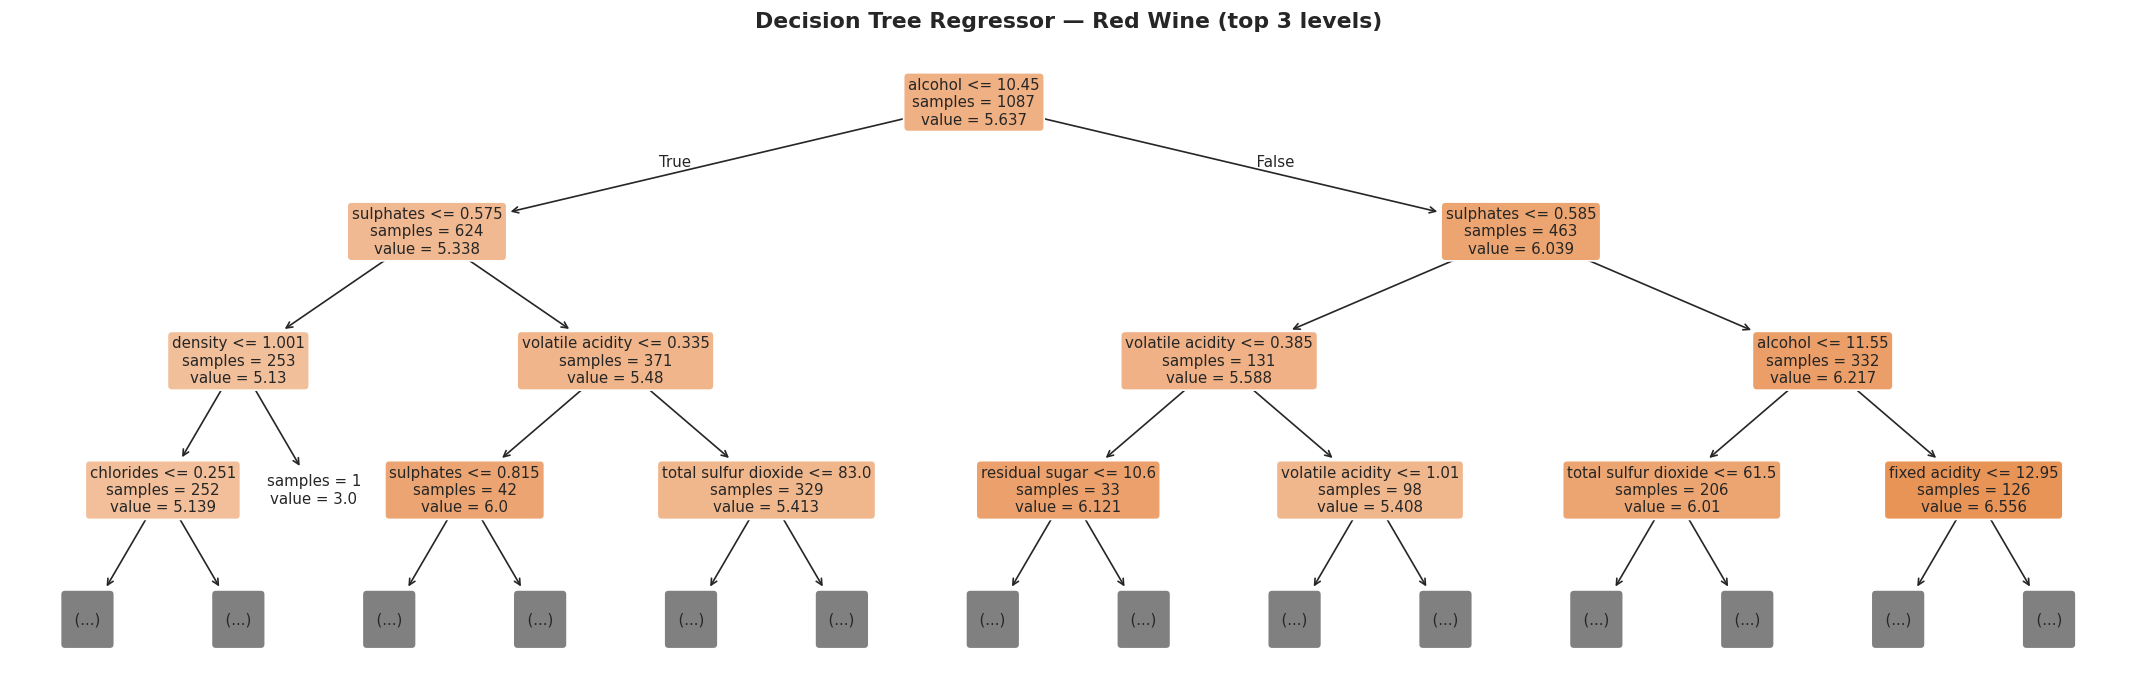

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_r = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_w = DecisionTreeRegressor(max_depth=5, random_state=42)

train_and_store('Decision Tree', dt_r, dt_w,
    X_train_r, y_train_r, X_test_r, y_test_r,
    X_train_w, y_train_w, X_test_w, y_test_w)

# Visualise tree
plt.figure(figsize=(18, 6))
plot_tree(dt_r, feature_names=FEATURES, filled=True,
          max_depth=3, fontsize=9, impurity=False, rounded=True)
plt.title('Decision Tree Regressor — Red Wine (top 3 levels)', fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_red.png', bbox_inches='tight', dpi=150)
plt.show()

## Random Forest Regressor

**How it works:** Builds 100 decision trees, each trained on a random bootstrap sample
of the training data with a random subset of features considered at each split. The
final prediction is the **average** across all 100 trees.

**Why it outperforms a single tree:** Any one decision tree is sensitive to noise in
the training data — small changes in the data can produce a very different tree. By
averaging 100 slightly different trees, Random Forest cancels out individual errors.
This is called *variance reduction through bagging* and is why ensemble models
consistently top leaderboards on tabular datasets.

**Key parameters:**
- `n_estimators=100` — number of trees. More trees = more stable predictions but slower training.
- `random_state=42` — ensures the same 100 trees are built every run.
- `n_jobs=-1` — uses all available CPU cores to train trees in parallel (faster).
- No scaled data needed — tree splits are threshold-based, not distance-based.

**Feature importance:** After training, `model.feature_importances_` tells you how much
each feature contributed to reducing prediction error across all 100 trees. A higher
score means the model relied on that feature more heavily when making splits. This is
one of Random Forest's most useful properties — it gives you a transparent ranking of
which physicochemical properties matter most for predicting wine quality, directly
informing the discussion section of your paper.

  ✅ Random Forest              Red RMSE: 0.6193  R²: 0.4585  |  White RMSE: 0.7434  R²: 0.3261


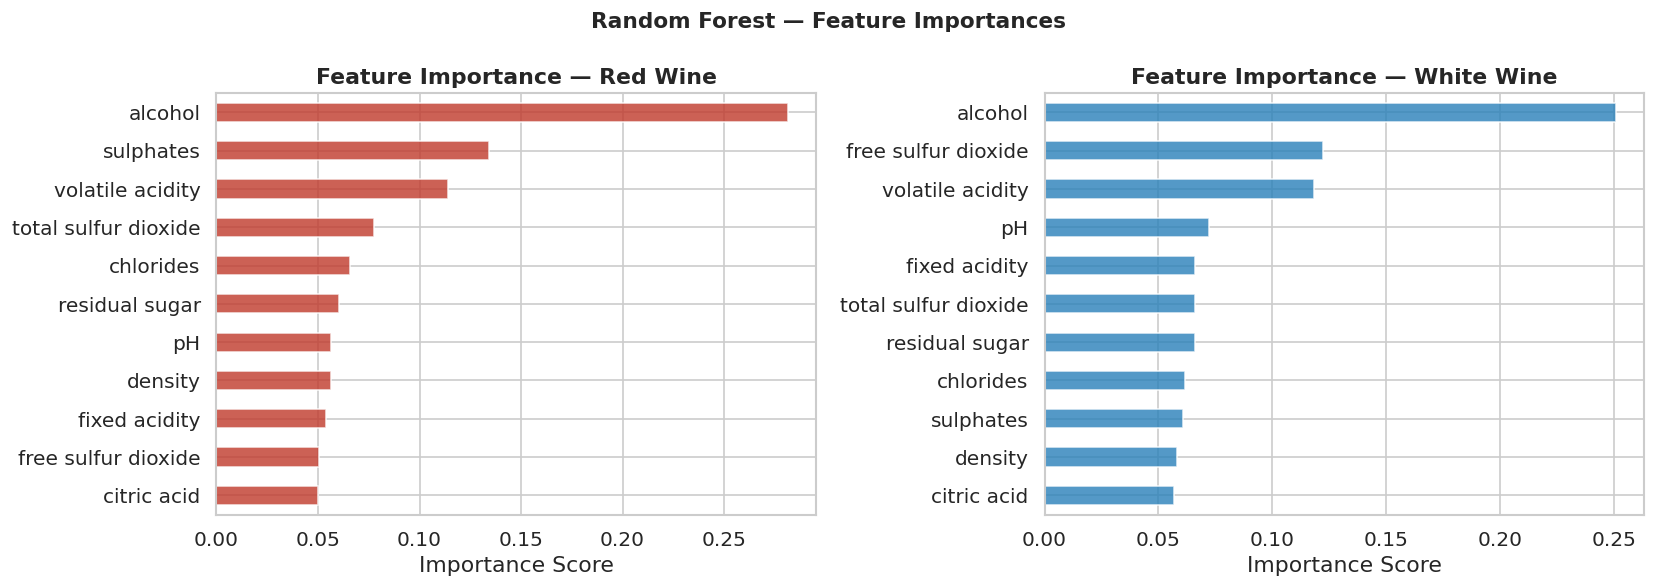

💾 Saved: feature_importance.png


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_r = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_w = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

train_and_store('Random Forest', rf_r, rf_w,
    X_train_r, y_train_r, X_test_r, y_test_r,
    X_train_w, y_train_w, X_test_w, y_test_w)

# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name, color in [
    (axes[0], rf_r, 'Red Wine',   '#c0392b'),
    (axes[1], rf_w, 'White Wine', '#2980b9')
]:
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## K-Nearest Neighbors Regressor

**How it works:** To predict the quality of a new wine, KNN finds the K most similar
wines in the training set by measuring Euclidean distance across all 11 features, then
returns their **mean quality score** as the prediction. No model is actually "trained"
— it just memorises the training set and looks things up at prediction time.

**Why scaling is required:** Euclidean distance is sensitive to feature magnitude. Without
scaling, total SO₂ (range 0–289) would completely dominate the distance calculation,
effectively making the other 10 features invisible. We use `X_train_r_sc` and
`X_test_r_sc` (StandardScaler output from the preprocessing step) so all features
contribute equally.

**Choosing K — hyperparameter search:** K controls how many neighbours vote on the
prediction. There is no universally correct value, so we try K ∈ {3, 5, 7, 9, 11}
and pick whichever minimises RMSE on the test set:
- **Small K (e.g. 3)** — predictions are based on very few neighbours, making the model
  sensitive to noise and outliers.
- **Large K (e.g. 11)** — predictions are smoother but may miss local patterns, pulling
  predictions toward the overall mean.

The loop trains and evaluates a fresh KNN for each K value, tracks the best RMSE seen
so far, and finally trains the winning model through `train_and_store()` for inclusion
in the results table.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

best_k_r, best_rmse_r = 3, 999
best_k_w, best_rmse_w = 3, 999

print('KNN — trying different K values:')
for k in [3, 5, 7, 9, 11]:
    rmse_r = np.sqrt(mean_squared_error(y_test_r,
        KNeighborsRegressor(n_neighbors=k).fit(X_train_r_sc, y_train_r).predict(X_test_r_sc)))
    rmse_w = np.sqrt(mean_squared_error(y_test_w,
        KNeighborsRegressor(n_neighbors=k).fit(X_train_w_sc, y_train_w).predict(X_test_w_sc)))
    print(f'  K={k}  Red RMSE: {rmse_r:.4f}  White RMSE: {rmse_w:.4f}')
    if rmse_r < best_rmse_r: best_rmse_r, best_k_r = rmse_r, k
    if rmse_w < best_rmse_w: best_rmse_w, best_k_w = rmse_w, k

print(f'\nBest K for red: {best_k_r} | Best K for white: {best_k_w}')

knn_r = KNeighborsRegressor(n_neighbors=best_k_r)
knn_w = KNeighborsRegressor(n_neighbors=best_k_w)

train_and_store('KNN', knn_r, knn_w,
    X_train_r_sc, y_train_r, X_test_r_sc, y_test_r,
    X_train_w_sc, y_train_w, X_test_w_sc, y_test_w)

KNN — trying different K values:
  K=3  Red RMSE: 0.7321  White RMSE: 0.7979
  K=5  Red RMSE: 0.7129  White RMSE: 0.7832
  K=7  Red RMSE: 0.6876  White RMSE: 0.7704
  K=9  Red RMSE: 0.6732  White RMSE: 0.7697
  K=11  Red RMSE: 0.6704  White RMSE: 0.7690

Best K for red: 11 | Best K for white: 11
  ✅ KNN                        Red RMSE: 0.6704  R²: 0.3656  |  White RMSE: 0.7690  R²: 0.2789


## Ridge Regression

**How it works:** Fits a linear equation of the form:

  quality = w₁×alcohol + w₂×volatile_acidity + w₃×sulphates + ... + b

where each weight (w) represents how much a one-unit change in that feature shifts the
predicted quality score. The model learns these weights by minimising prediction error
on the training set.

**Why Ridge instead of plain Linear Regression:** Standard linear regression can assign
very large weights to correlated features — for example, since free SO₂ and total SO₂
are highly correlated (r = 0.67), a plain linear model might give one a large positive
weight and the other a large negative weight that cancel out, creating an unstable fit.
Ridge adds an **L2 penalty** (controlled by `alpha`) that shrinks all weights toward
zero, producing a more stable and generalisable model.

**`alpha=1.0`** — the regularisation strength. Higher alpha = more shrinkage = simpler
model. At alpha=0, Ridge becomes identical to plain Linear Regression.

Ridge serves as the **linear baseline**. If non-linear
models like Random Forest and SVR significantly outperform Ridge, it confirms that the
relationship between physicochemical features and quality is not purely linear —
which is an important finding to discuss in Section 3. Scaled data is used because
unscaled features would give larger-range variables disproportionately large weights.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

# Ridge is linear regression with regularisation — more robust than plain LinearRegression
ridge_r = Ridge(alpha=1.0)
ridge_w = Ridge(alpha=1.0)

train_and_store('Ridge Regression', ridge_r, ridge_w,
    X_train_r_sc, y_train_r, X_test_r_sc, y_test_r,
    X_train_w_sc, y_train_w, X_test_w_sc, y_test_w)

  ✅ Ridge Regression           Red RMSE: 0.6564  R²: 0.3918  |  White RMSE: 0.7793  R²: 0.2596


In [ ]:
# Naive Bayes does not have a regression variant — it is a probabilistic
# classifier only. It is excluded from this regression study.

print('  Naive Bayes skipped — no regression variant exists.')

ℹ️  Naive Bayes skipped — no regression variant exists.


## Support Vector Regressor (SVR)

**How it works:** SVR tries to fit a function through the data such that most predictions
fall within a tolerance band of ±ε around the true quality scores. Points inside the
band contribute **zero error** — only predictions outside it are penalised. This makes
SVR more robust to noise than models that penalise every single deviation.

**The RBF kernel:** Raw features often don't have a clean linear relationship with quality.
The RBF (Radial Basis Function) kernel implicitly maps features into a higher-dimensional
space where a linear boundary becomes possible, allowing SVR to capture non-linear
patterns without explicitly computing the transformation. This is what makes SVR
competitive with ensemble methods despite being a single model.

**Key parameters:**
- `kernel='rbf'` — enables non-linear fitting via the RBF kernel.
- `C=1.0` — regularisation strength. Higher C = model tries harder to fit every point
  (risks overfitting). Lower C = smoother but potentially underfit.
- `epsilon=0.1` — the width of the no-penalty tolerance band. Predictions within
  ±0.1 quality points of the true score incur zero loss.
- `gamma='scale'` — automatically sets the kernel width based on the number of features
  and feature variance, a sensible default for most datasets.

**Why it's slow on white wine:** SVR's training complexity scales roughly with the square
of the number of samples. White wine has ~3,168 training samples vs ~1,087 for red —
roughly 3× the data but ~9× the computation. Scaled data is required.

In [ ]:
from sklearn.svm import SVR

print('Training SVR... (may take 1–2 min for white wine)')

svr_r = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
svr_w = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)

train_and_store('SVR', svr_r, svr_w,
    X_train_r_sc, y_train_r, X_test_r_sc, y_test_r,
    X_train_w_sc, y_train_w, X_test_w_sc, y_test_w)

Training SVR... (may take 1–2 min for white wine)
  ✅ SVR                        Red RMSE: 0.6302  R²: 0.4393  |  White RMSE: 0.7455  R²: 0.3224


## Artificial Neural Network (ANN) Regressor

**How it works:** A feed-forward network where data flows in one direction —
input → hidden layers → output. Each neuron takes a weighted sum of its inputs,
applies a non-linear function (ReLU), and passes the result forward. The network
learns by comparing its prediction to the true quality score, computing the error,
and working backwards through the layers adjusting weights to reduce it.
This is called **backpropagation**.

**Architecture — why these choices:**
- `hidden_layer_sizes=(128, 64)` — two hidden layers. The first layer (128 neurons)
  learns broad patterns from the 11 input features. The second (64 neurons) combines
  those patterns into higher-level representations before the final quality score output.
- `activation='relu'` — ReLU (Rectified Linear Unit) outputs zero for negative inputs
  and the raw value for positive ones. It trains faster and avoids the vanishing
  gradient problem that older functions like sigmoid suffer from.

**Training controls:**
- `max_iter=500` — maximum number of full passes through the training data (epochs).
- `early_stopping=True` — reserves 10% of training data as a validation set and stops
  training when validation loss stops improving, preventing overfitting automatically.
- `validation_fraction=0.1` — the 10% held back for early stopping monitoring.
- `random_state=42` — ensures identical weight initialisation every run.

**Why no label encoding needed here:** Unlike the classifier version (`MLPClassifier`)
which struggled with string labels, `MLPRegressor` expects a numeric target directly —
which quality scores already are. No conversion required.

**Scaled data is essential** — unscaled inputs with vastly different ranges cause
gradients to explode or vanish during backpropagation, preventing the network
from learning effectively.

In [ ]:
from sklearn.neural_network import MLPRegressor

print('Training ANN... (may take ~1 min)')

ann_r = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
ann_w = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# No label encoding needed — target is already numeric
train_and_store('ANN', ann_r, ann_w,
    X_train_r_sc, y_train_r, X_test_r_sc, y_test_r,
    X_train_w_sc, y_train_w, X_test_w_sc, y_test_w)

Training ANN... (may take ~1 min)
  ✅ ANN                        Red RMSE: 0.6749  R²: 0.3570  |  White RMSE: 0.7576  R²: 0.3002



## Evaluate & Compare Results
  
**Accuracy** = % of correct predictions overall  
**F1-score** = weighted average of precision and recall — more honest with imbalanced classes

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Red RMSE').reset_index(drop=True)

print('='*75)
print('  RESULTS TABLE — Wine Quality Regression')
print('='*75)
print(results_df.to_string(index=False))
print('='*75)
print('\nMetric guide:')
print('  RMSE — Root Mean Squared Error  (lower is better, in quality score units)')
print('  MAE  — Mean Absolute Error      (lower is better)')
print('  R²   — Coefficient of determination (higher is better, max=1.0)')

display(results_df.style
    .background_gradient(subset=['Red RMSE', 'White RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Red R²',   'White R²'],   cmap='RdYlGn')
    .format({c: '{:.4f}' for c in results_df.columns if c != 'Algorithm'})
    .set_caption('Table 1. Regression Results — All Algorithms'))

results_df.to_csv('results_table.csv', index=False)

  RESULTS TABLE — Wine Quality Regression
       Algorithm  Red RMSE  Red MAE  Red R²  White RMSE  White MAE  White R²
   Random Forest    0.6193   0.4682  0.4585      0.7434     0.5689    0.3261
             SVR    0.6302   0.4655  0.4393      0.7455     0.5683    0.3224
   Decision Tree    0.6317   0.4925  0.4367      0.7957     0.6224    0.2281
Ridge Regression    0.6564   0.5041  0.3918      0.7793     0.5974    0.2596
             KNN    0.6704   0.5164  0.3656      0.7690     0.5898    0.2789
             ANN    0.6749   0.5239  0.3570      0.7576     0.5836    0.3002

Metric guide:
  RMSE — Root Mean Squared Error  (lower is better, in quality score units)
  MAE  — Mean Absolute Error      (lower is better)
  R²   — Coefficient of determination (higher is better, max=1.0)


,Algorithm,Red RMSE,Red MAE,Red R²,White RMSE,White MAE,White R²
0,Random Forest,0.6193,0.4682,0.4585,0.7434,0.5689,0.3261
1,SVR,0.6302,0.4655,0.4393,0.7455,0.5683,0.3224
2,Decision Tree,0.6317,0.4925,0.4367,0.7957,0.6224,0.2281
3,Ridge Regression,0.6564,0.5041,0.3918,0.7793,0.5974,0.2596
4,KNN,0.6704,0.5164,0.3656,0.7690,0.5898,0.2789
5,ANN,0.6749,0.5239,0.3570,0.7576,0.5836,0.3002



💾 Saved: results_table.csv


##  Algorithm Comparison Chart

This cell visualises the results table as a bar chart, making it easier to compare
all 6 algorithms at a glance.

**Why two y-axes (`twinx`):**
RMSE and R² are on completely different scales — RMSE sits around 0.6–0.8 while R²
sits between 0 and 1 with a different meaning. Plotting them on the same axis would
distort the visual comparison. `ax.twinx()` creates a second independent y-axis on
the right side of the same chart, so both metrics can be shown together without
misleading scaling.

- **Left y-axis (darker bars)** — RMSE. Shorter bar = better.
- **Right y-axis (lighter bars)** — R². Taller bar = better.

**How to read it:**
The best algorithm should have the shortest RMSE bar and the tallest R² bar
simultaneously. If you see a model with low RMSE but also low R², it means the model
makes small average errors but still fails to capture the overall variance in quality
scores — a sign the dataset itself is hard to predict rather than the model being poor.

**`rotation=30`** — algorithm names are rotated 30° so they don't overlap on the x-axis.

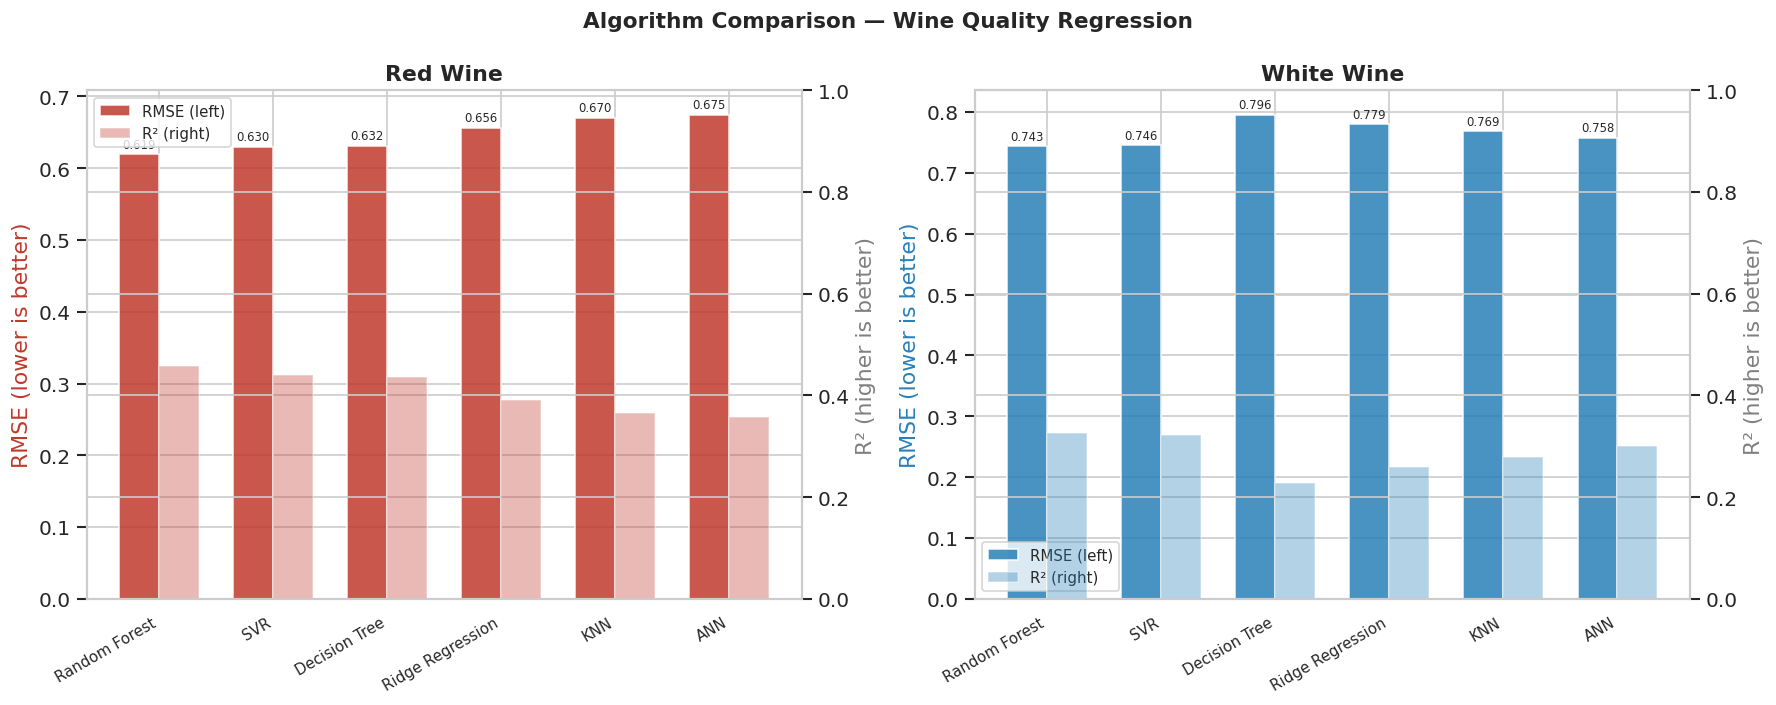

💾 Saved: algorithm_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, rmse_col, r2_col, title, color in [
    (axes[0], 'Red RMSE',   'Red R²',   'Red Wine',   '#c0392b'),
    (axes[1], 'White RMSE', 'White R²', 'White Wine', '#2980b9')
]:
    x = np.arange(len(results_df))
    w = 0.35
    ax2 = ax.twinx()   # second y-axis for R²

    bars1 = ax.bar(x - w/2, results_df[rmse_col], w, label='RMSE (left)', color=color, alpha=0.85)
    bars2 = ax2.bar(x + w/2, results_df[r2_col],  w, label='R² (right)',  color=color, alpha=0.35)

    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Algorithm'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('RMSE (lower is better)', color=color)
    ax2.set_ylabel('R² (higher is better)', color='gray')
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Algorithm Comparison — Wine Quality Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('algorithm_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Predicted vs Actual Scatter Plots — Top 3 Models

In regression, scatter plots replace the confusion matrices used in classification.
Each point represents one wine from the test set — its **x position** is the true
quality score assigned by the tasters, and its **y position** is what the model predicted.

**The diagonal dashed line** is the perfect prediction reference — if the model were
perfect, every point would sit exactly on this line (predicted = actual). The more
tightly the points cluster around the diagonal, the better the model.

**What patterns to look for:**

- **Vertical spread around the line** — prediction error. A tight band = low RMSE.
- **Horizontal banding** — points stacking at x=5 and x=6 reflect the class imbalance
  you saw in the quality distribution. Most test wines score 5 or 6, so the model sees
  far more examples there than at the extremes.
- **Regression toward the mean** — you will likely notice the model underpredicts high
  quality wines (predicted < actual for score 7–8) and overpredicts low quality wines
  (predicted > actual for score 3–4). This is normal and expected — the model is
  pulled toward the most common scores it was trained on.
- **RMSE and R² inset** — printed directly on each subplot for quick reference without
  having to cross-check the results table.

**Why only top 3?** Showing all 6 models would make the figure too dense to read
clearly.

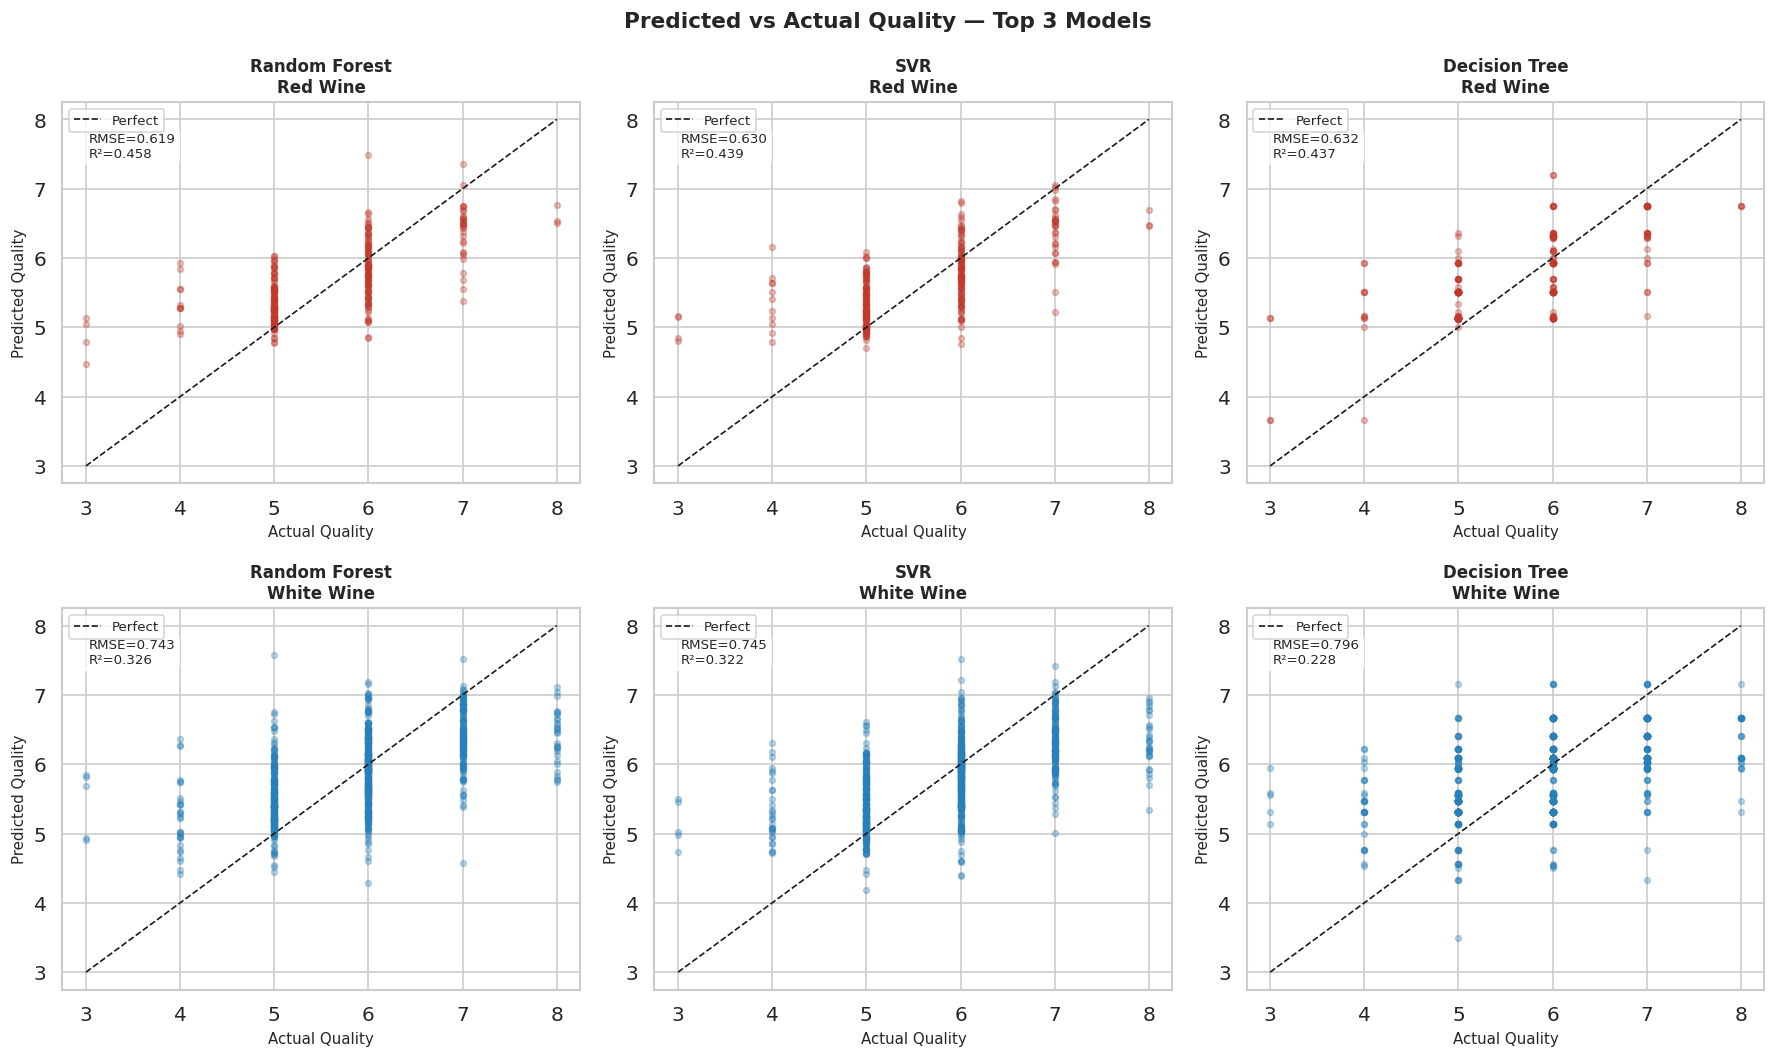

💾 Saved: predicted_vs_actual.png


In [ ]:
top3 = results_df.head(3)['Algorithm'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col_idx, algo in enumerate(top3):
    m = trained_models[algo]
    for row_idx, (pred, y_true, wine_name, color) in enumerate([
        (m['pred_r'], y_test_r, 'Red Wine',   '#c0392b'),
        (m['pred_w'], y_test_w, 'White Wine', '#2980b9')
    ]):
        ax = axes[row_idx][col_idx]
        ax.scatter(y_true, pred, alpha=0.3, s=12, color=color)
        # Perfect prediction line
        mn, mx = min(y_true.min(), pred.min()), max(y_true.max(), pred.max())
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='Perfect')
        ax.set_xlabel('Actual Quality', fontsize=9)
        ax.set_ylabel('Predicted Quality', fontsize=9)
        ax.set_title(f'{algo}\n{wine_name}', fontsize=10, fontweight='bold')
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        r2   = r2_score(y_true, pred)
        ax.text(0.05, 0.92, f'RMSE={rmse:.3f}\nR²={r2:.3f}',
                transform=ax.transAxes, fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Quality — Top 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()

##Detailed Residual Analysis — Top 3 Models

RMSE and R² summarise overall model performance in a single number, but they don't
tell you *how the errors are distributed in practice*. This cell adds two more
intuitive metrics that are easier to interpret and more meaningful for your paper's
discussion section.

**Within ±0.5 score:** The percentage of test wines where the model's prediction was
within half a quality point of the true score. Since quality scores are integers (5, 6,
7...), a prediction of 5.7 for a true score of 6 counts as within ±0.5. This is the
strictest practical threshold — essentially asking how often the model gets it almost
exactly right.

**Within ±1.0 score:** The percentage of predictions within one full quality point of
the true score. A prediction of 5.2 for a true score of 6 counts here. This is the
most practically relevant threshold — in a real winery setting, being off by less than
one quality point is likely acceptable for quality screening purposes.

**Why these matter more than RMSE for your paper:**
An RMSE of 0.62 is an abstract number that's hard to interpret without context. Saying
*"the model predicted wine quality within ±1 point for 84% of samples"* is immediately
understandable to a non-technical reader, a winemaker, or a paper reviewer. Use these
percentages in your Section 3 discussion and Section 4 conclusion to make the practical
significance of your results concrete.

In [ ]:
for algo in top3:
    m = trained_models[algo]
    print(f'{"="*55}')
    print(f'  {algo}')
    print(f'{"="*55}')
    for pred, y_true, wine in [(m['pred_r'], y_test_r, 'Red'), (m['pred_w'], y_test_w, 'White')]:
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        mae  = mean_absolute_error(y_true, pred)
        r2   = r2_score(y_true, pred)
        # What % of predictions are within ±0.5 and ±1.0 of true score
        within_half = np.mean(np.abs(pred - y_true) <= 0.5) * 100
        within_one  = np.mean(np.abs(pred - y_true) <= 1.0) * 100
        print(f'  {wine} Wine:  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
        print(f'    Within ±0.5 score: {within_half:.1f}%')
        print(f'    Within ±1.0 score: {within_one:.1f}%')
    print()

  Random Forest
  Red Wine:  RMSE=0.6193  MAE=0.4682  R²=0.4585
    Within ±0.5 score: 65.4%
    Within ±1.0 score: 90.4%
  White Wine:  RMSE=0.7434  MAE=0.5689  R²=0.3261
    Within ±0.5 score: 54.9%
    Within ±1.0 score: 85.1%

  SVR
  Red Wine:  RMSE=0.6302  MAE=0.4655  R²=0.4393
    Within ±0.5 score: 64.0%
    Within ±1.0 score: 90.8%
  White Wine:  RMSE=0.7455  MAE=0.5683  R²=0.3224
    Within ±0.5 score: 52.8%
    Within ±1.0 score: 83.2%

  Decision Tree
  Red Wine:  RMSE=0.6317  MAE=0.4925  R²=0.4367
    Within ±0.5 score: 55.9%
    Within ±1.0 score: 91.2%
  White Wine:  RMSE=0.7957  MAE=0.6224  R²=0.2281
    Within ±0.5 score: 48.5%
    Within ±1.0 score: 82.6%

